In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df =  pd.read_csv('IPL.csv')

In [5]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


**Basic INFO**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [7]:
print(f"your rows are {df.shape[0]} and your column are {df.shape[1]}")


your rows are 74 and your column are 20


In [8]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


1. Which team won the most matches?


In [9]:
match_wins = df['match_winner'].value_counts()

<Axes: ylabel='match_winner'>

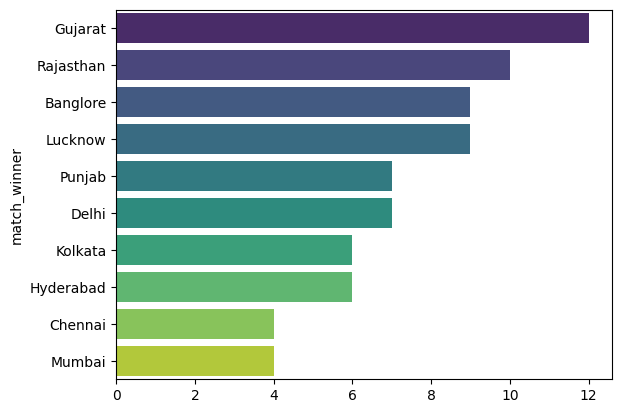

In [10]:
sns.barplot(y = match_wins.index, x = match_wins.values, palette='viridis')

2. Toss Decision

<Axes: xlabel='toss_decision', ylabel='count'>

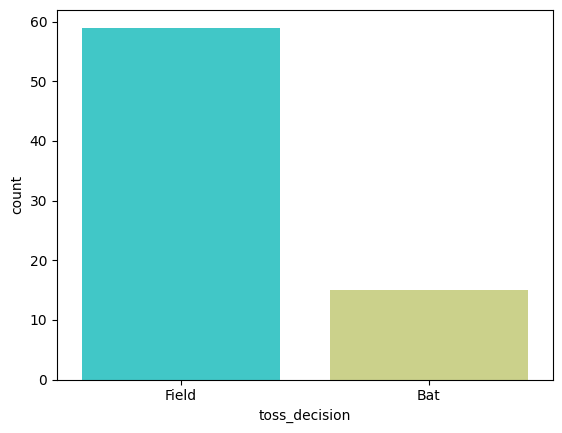

In [11]:
sns.countplot(x = df['toss_decision'], palette='rainbow')

3. Toss VS Match winner


In [12]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4. How to team Win Runs Vs Wickets

Text(0.5, 1.0, 'Won By')

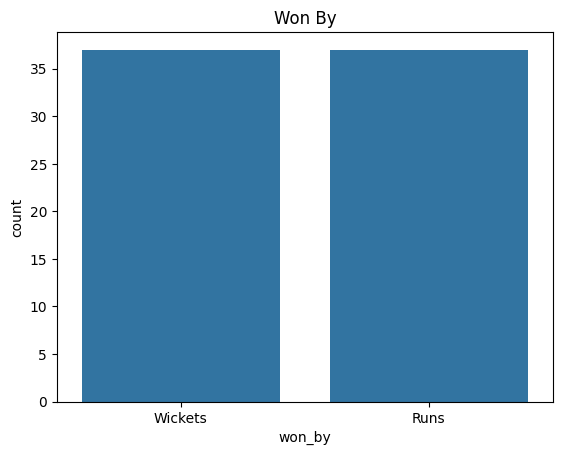

In [13]:

sns.countplot(x = df['won_by'])
plt.title("Won By")


**Key Player Performance**


1 most *player of the Match* Awards

In [14]:
count = df['player_of_the_match'].value_counts().head(10)
count

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


Text(0.5, 1.0, 'Top 10 Man of The Match')

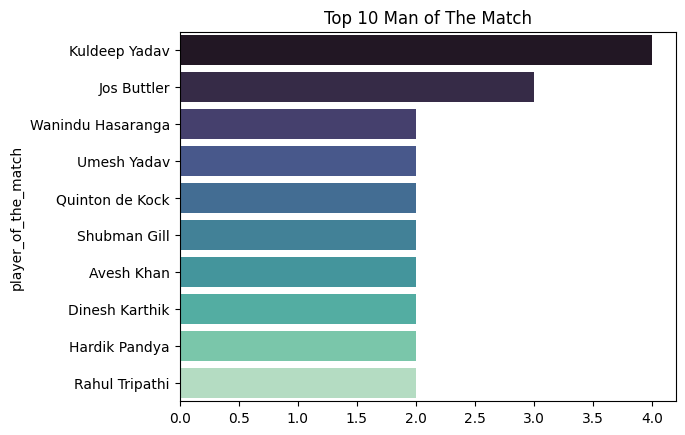

In [15]:

sns.barplot(x = count.values, y = count.index, palette='mako')
plt.title('Top 10 Man of The Match')

2. Two Top Scorers

In [16]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
high

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


<Axes: ylabel='top_scorer'>

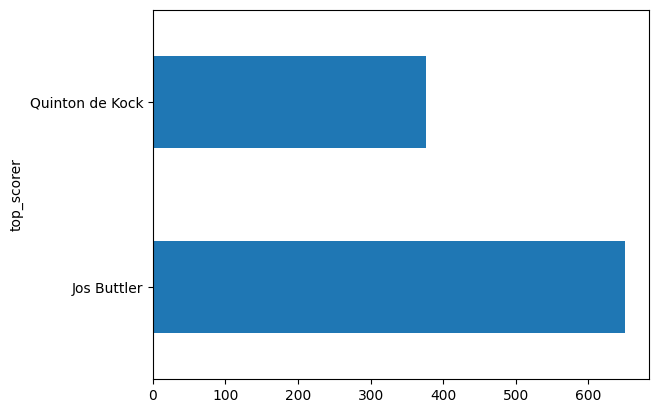

In [17]:
high.plot(kind = 'barh')

3. 10 best bolling fegure

In [26]:
df['highest_wickets']  = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])

df['highest_wickets']  = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers

,highest_wickets
best_bowling,
Yuzvendra Chahal,17
Jasprit Bumrah,11
Kuldeep Yadav,11
Rashid Khan,11
Josh Hazlewood,10
Kagiso Rabada,10
Avesh Khan,10
Umran Malik,9
Wanindu Hasaranga,9


<Axes: ylabel='best_bowling'>

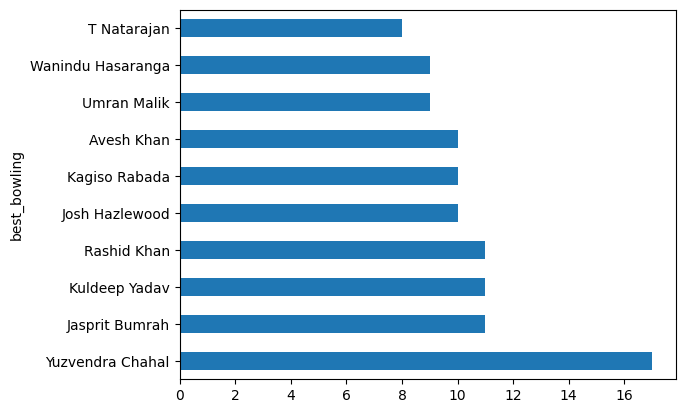

In [28]:
top_bowlers.plot(kind='barh')

**Venue Analsis**

Most Matches played by venue

In [29]:
venue_count = df['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

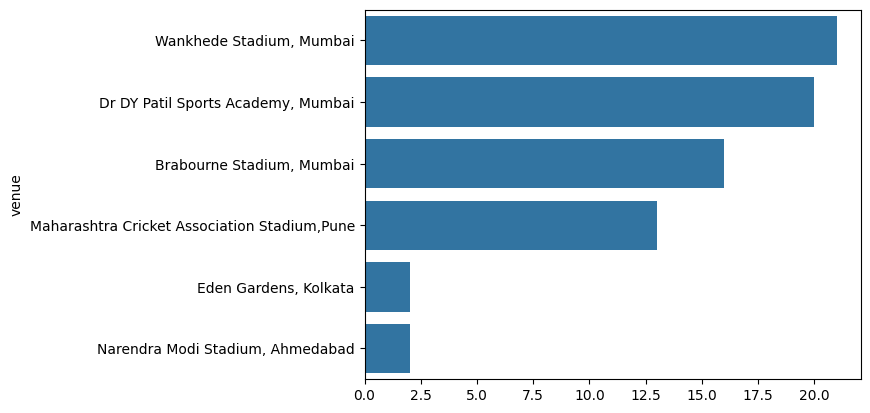

In [31]:
sns.barplot(y=venue_count.index, x=venue_count.values)

**Who won the Highest Margin by Run**

In [32]:
df[df['won_by']  == 'Runs'].sort_values(by = 'margin', ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91
